# tmp — dec25

**Motivation**: scratch notebook <br>

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from test.nonstationary import (
    run_all_experiments,
    compute_recovery_metrics,
    print_recovery_metrics,
    run_curvature_ablation,
)

======================================================================

NONSTATIONARY OPTIMIZATION EXPERIMENTS

======================================================================

[1/5] Running Drifting Quadratic experiment...

[2/5] Running Abrupt Shift experiment...

...

[4/5] Running Online Regression experiment...

[5/5] Running Rotating Gradient experiment...

======================================================================

All experiments complete!

======================================================================

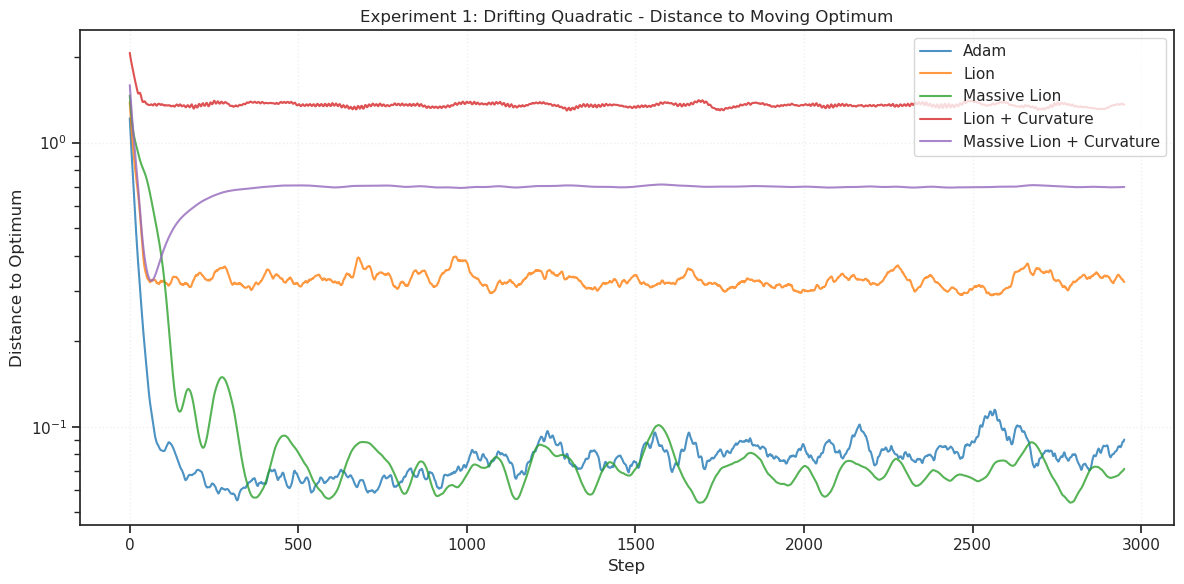

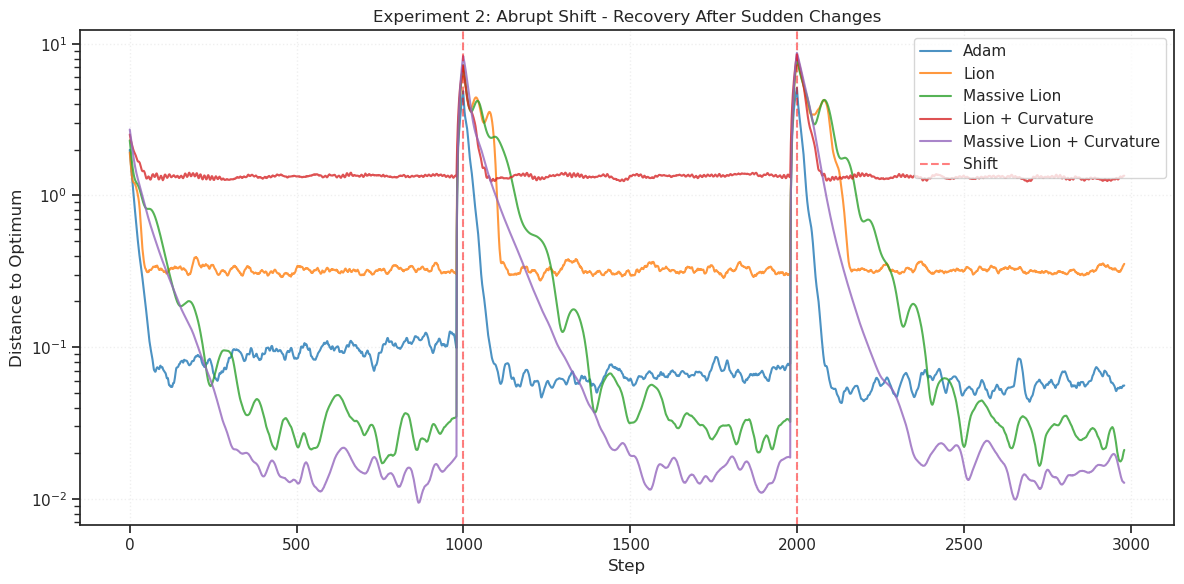

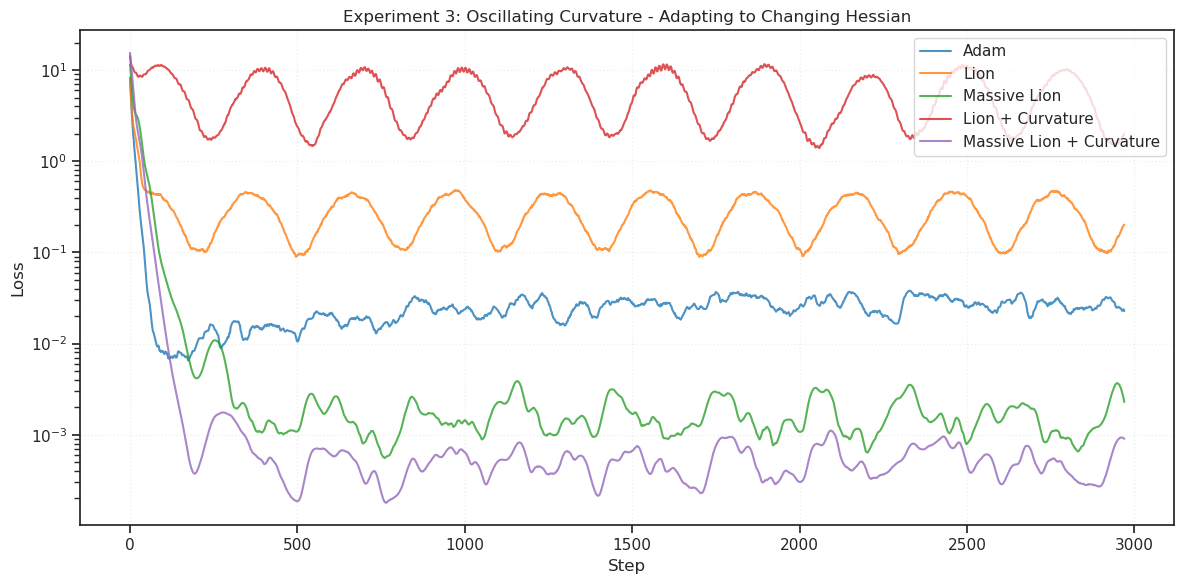

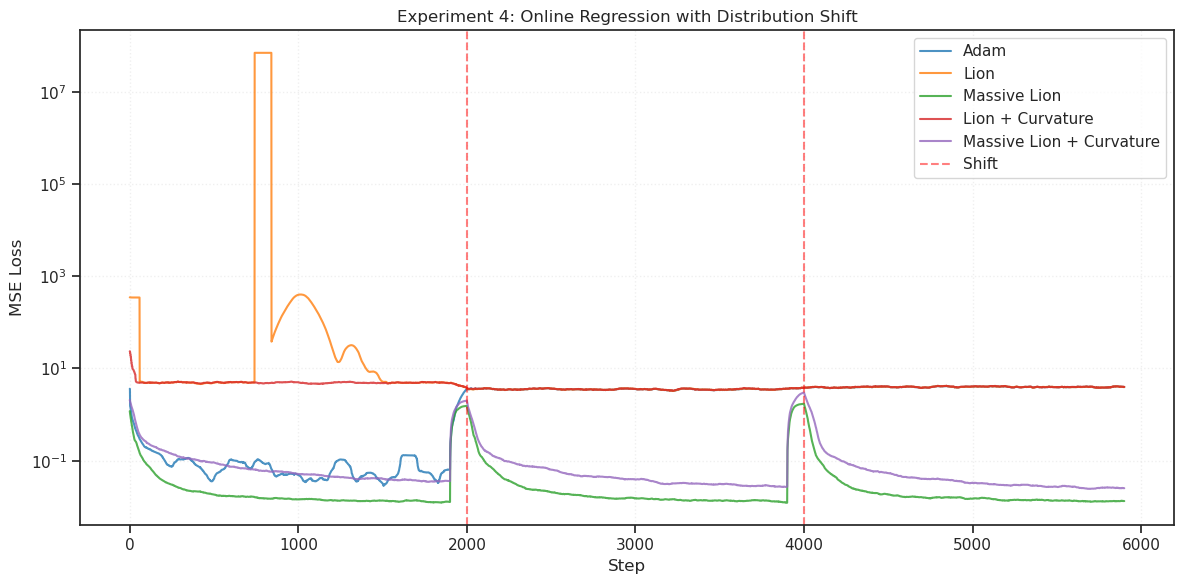

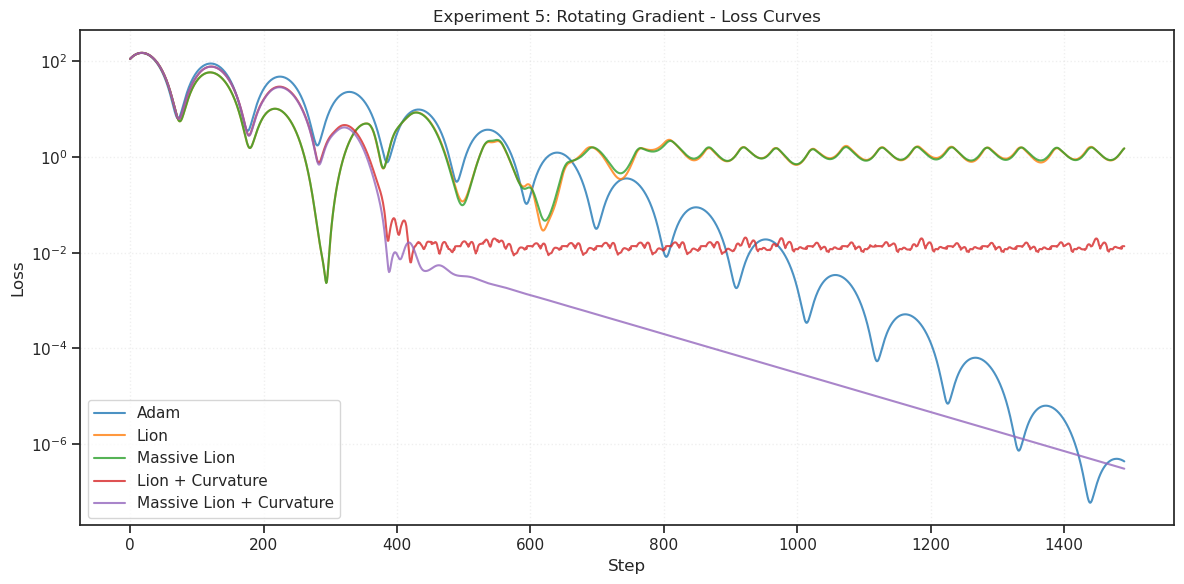

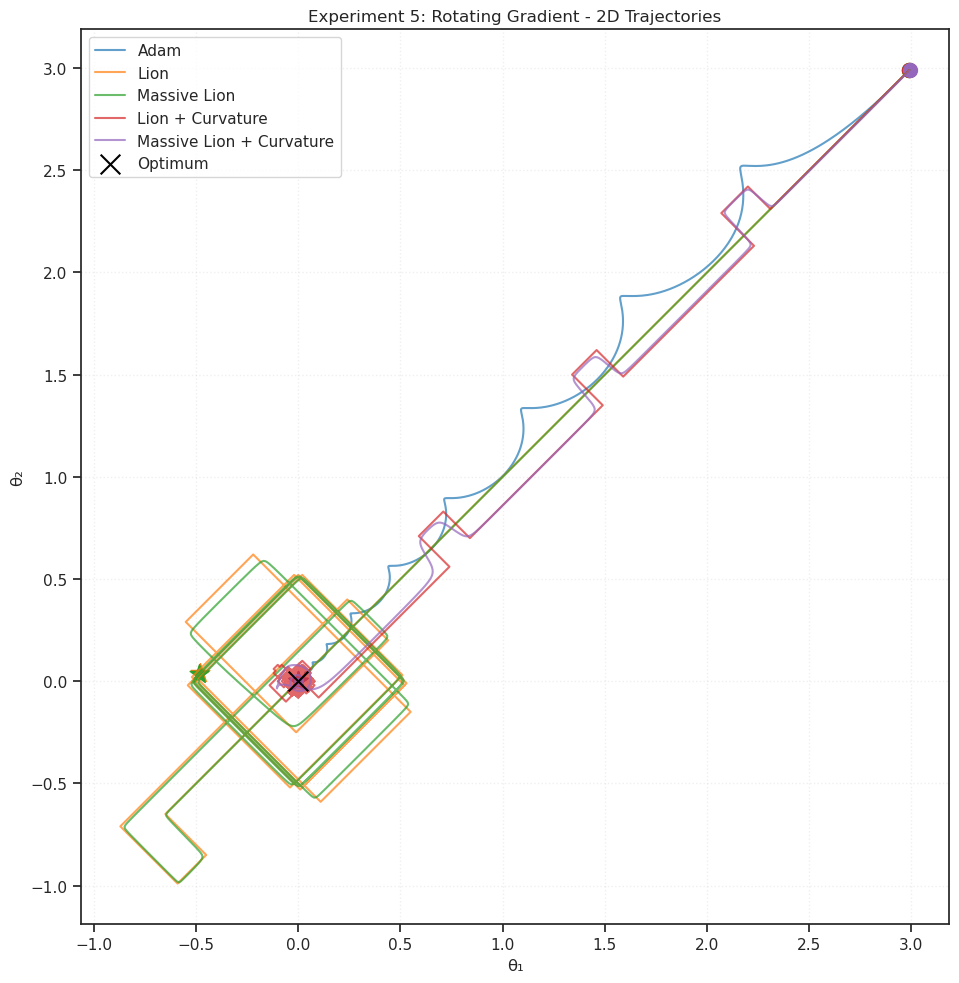

In [3]:
all_results = run_all_experiments(save_plots=False, show_plots=True)

======================================================================

NONSTATIONARY OPTIMIZATION EXPERIMENTS

======================================================================

[1/5] Running Drifting Quadratic experiment...

[2/5] Running Abrupt Shift experiment...

...

[4/5] Running Online Regression experiment...

[5/5] Running Rotating Gradient experiment...

======================================================================

All experiments complete!

======================================================================

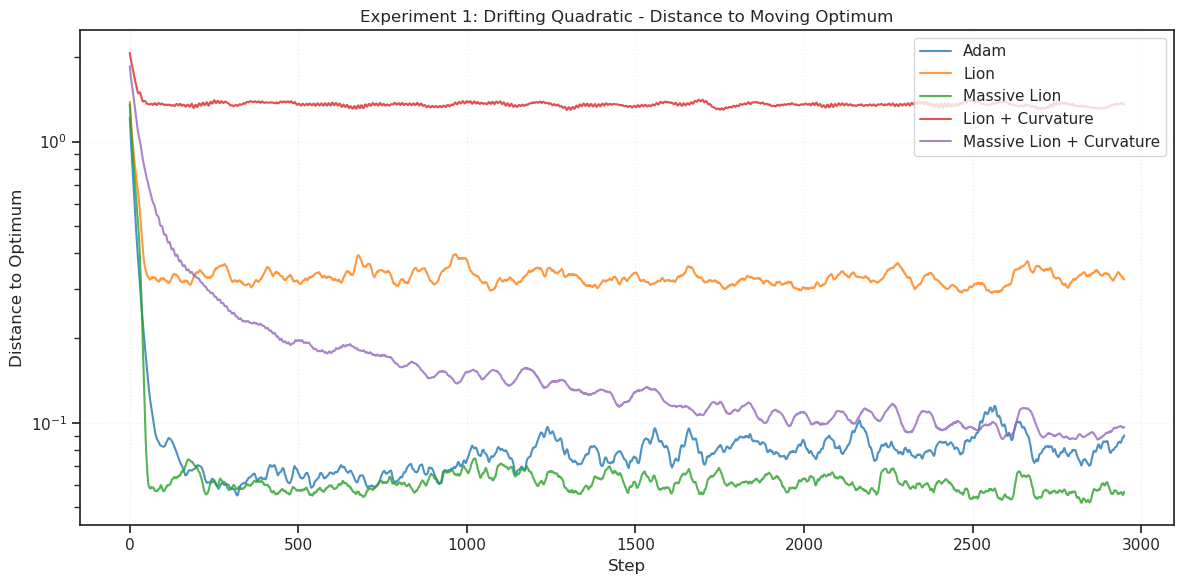

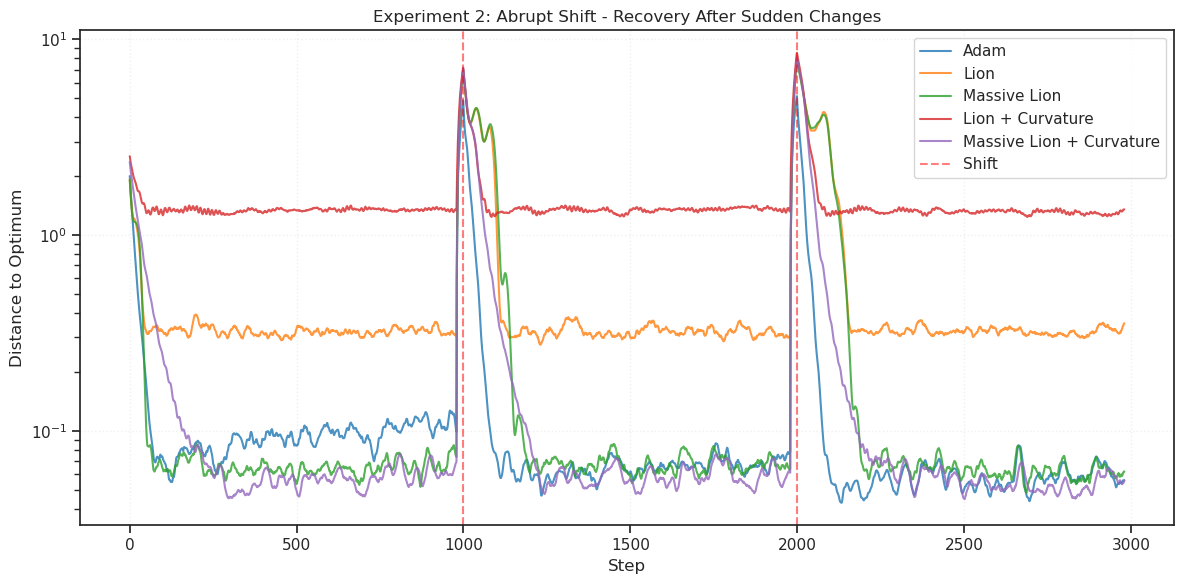

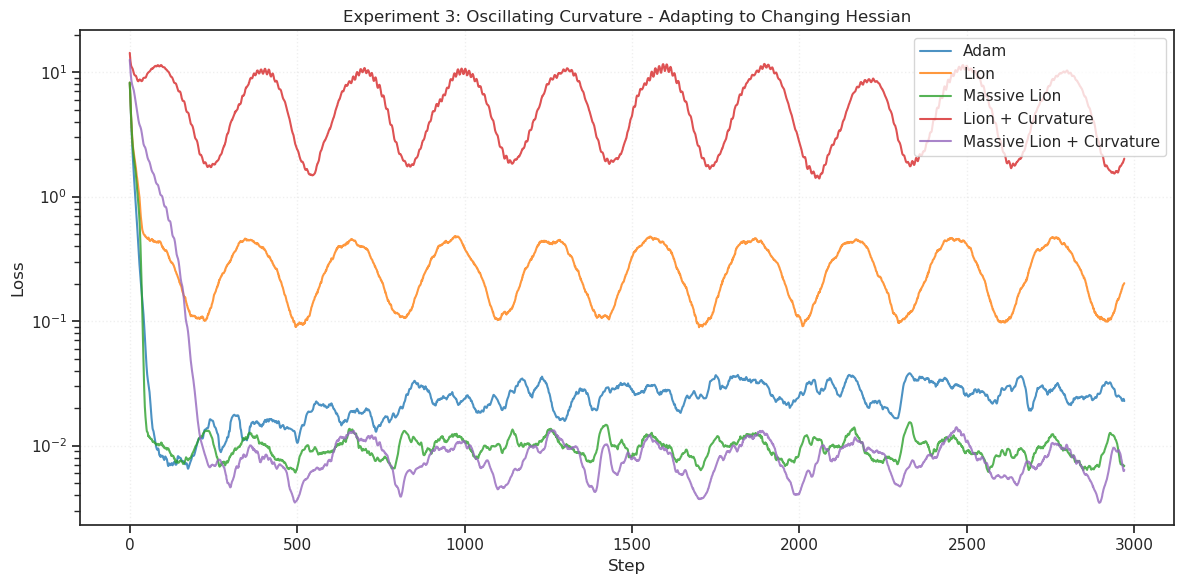

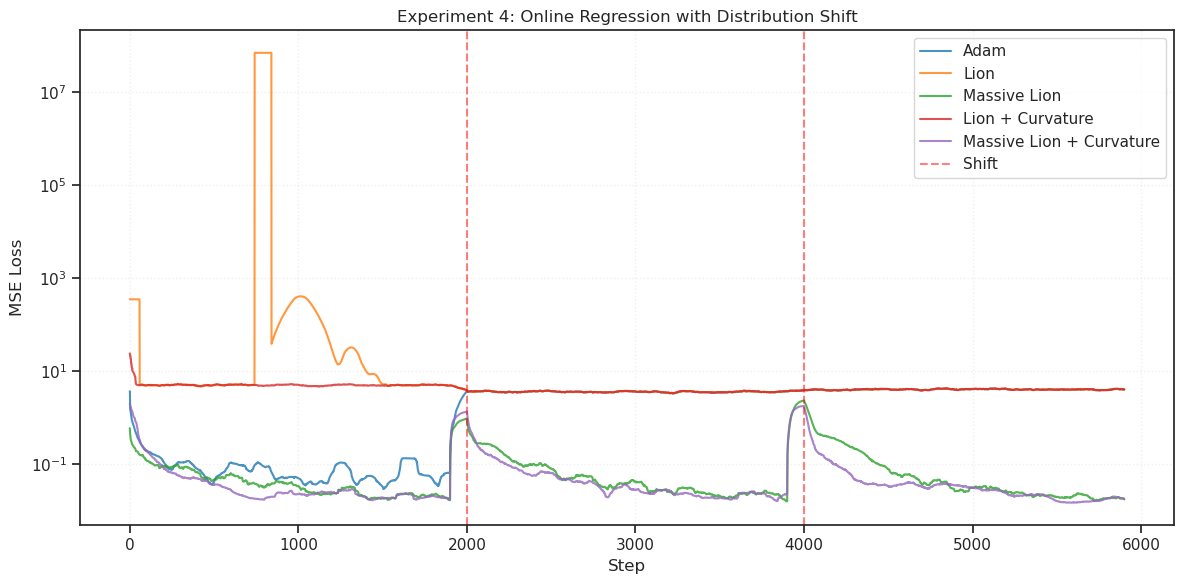

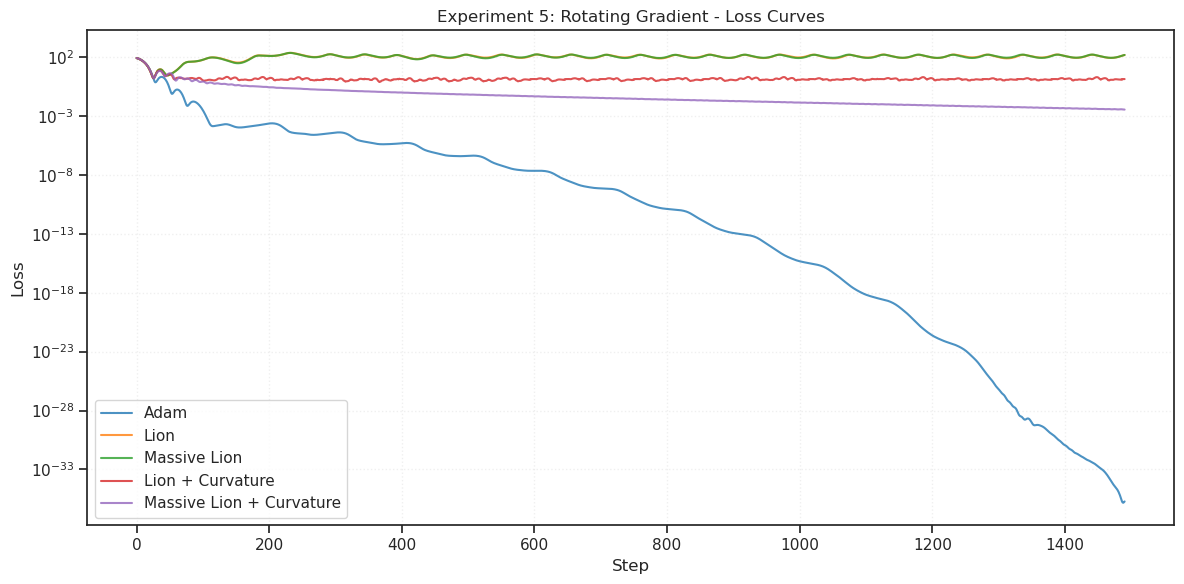

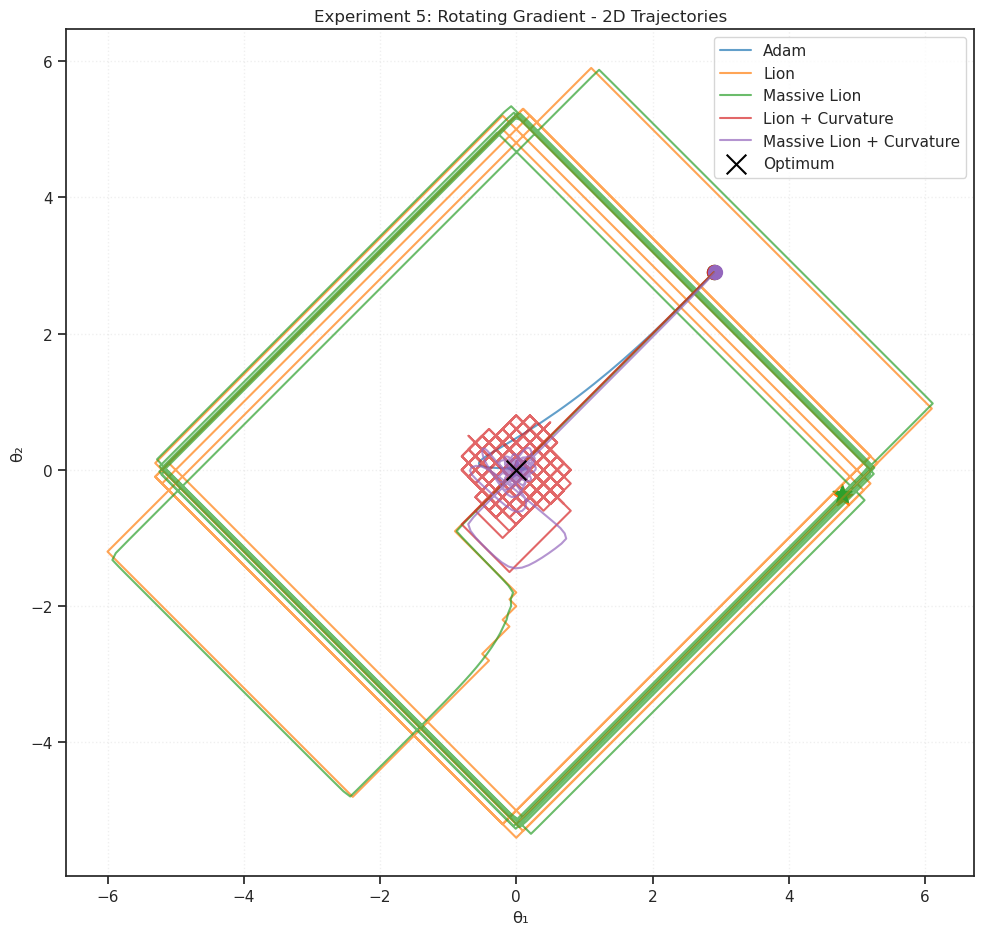

======================================================================

NONSTATIONARY OPTIMIZATION EXPERIMENTS

======================================================================

[1/5] Running Drifting Quadratic experiment...

[2/5] Running Abrupt Shift experiment...

...

[4/5] Running Online Regression experiment...

[5/5] Running Rotating Gradient experiment...

======================================================================

All experiments complete!

======================================================================

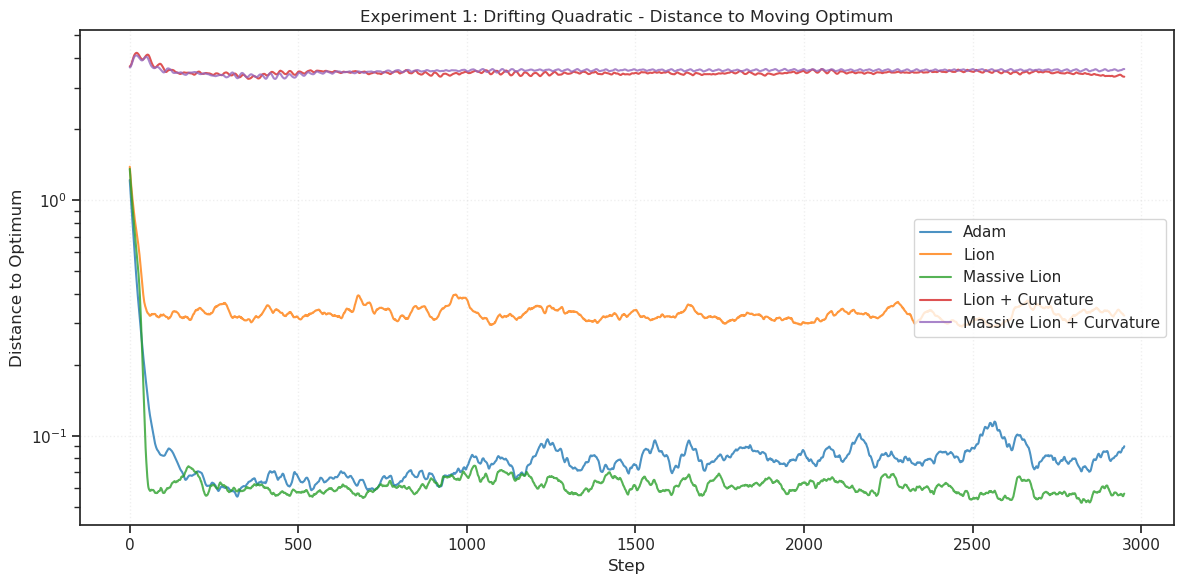

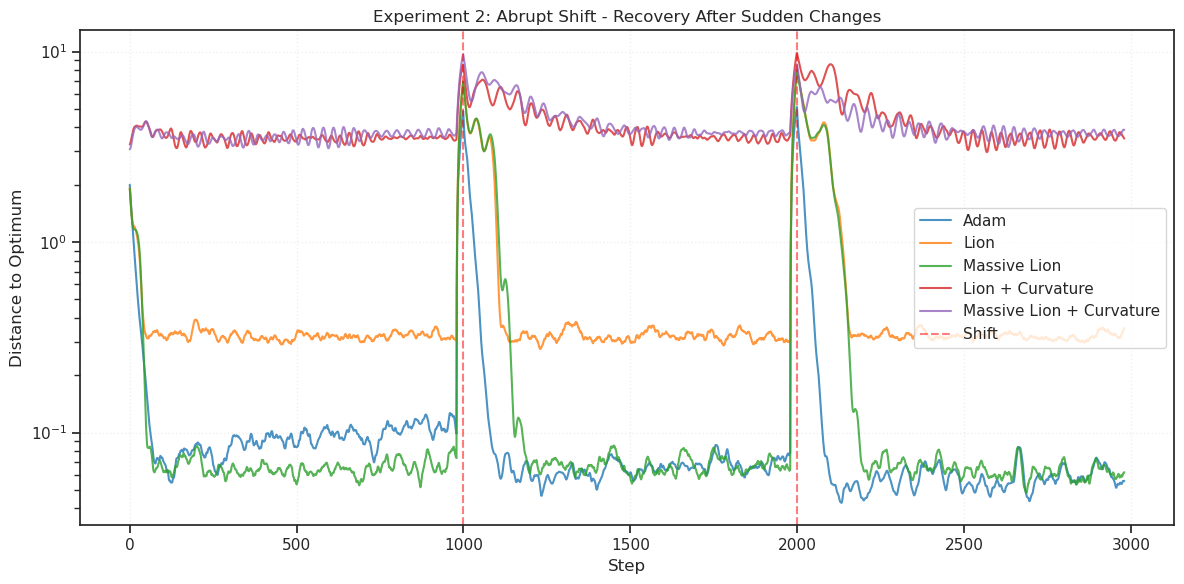

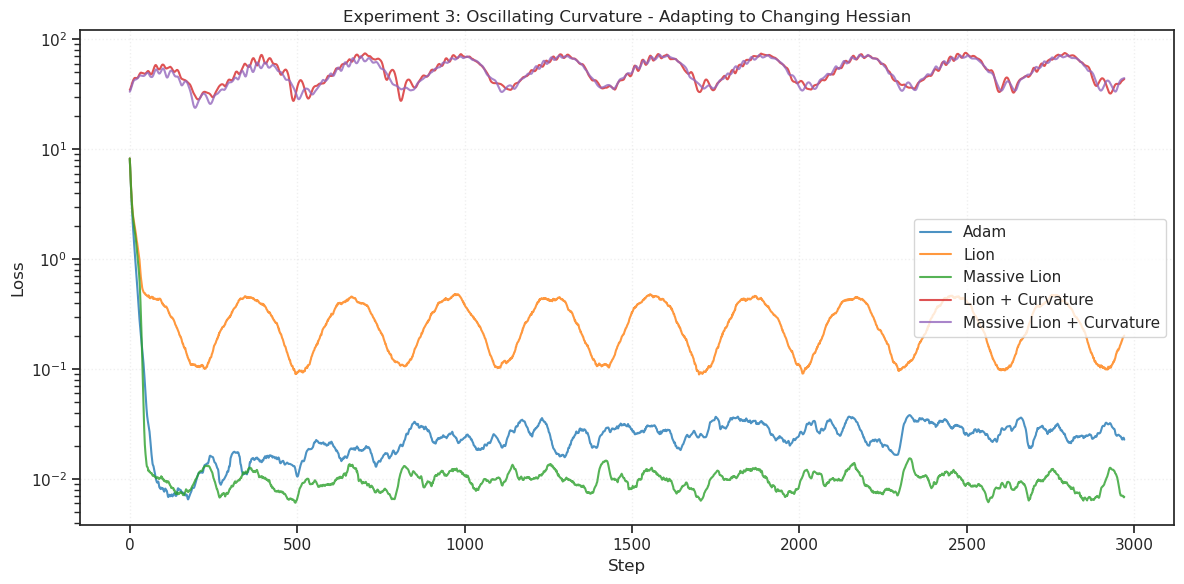

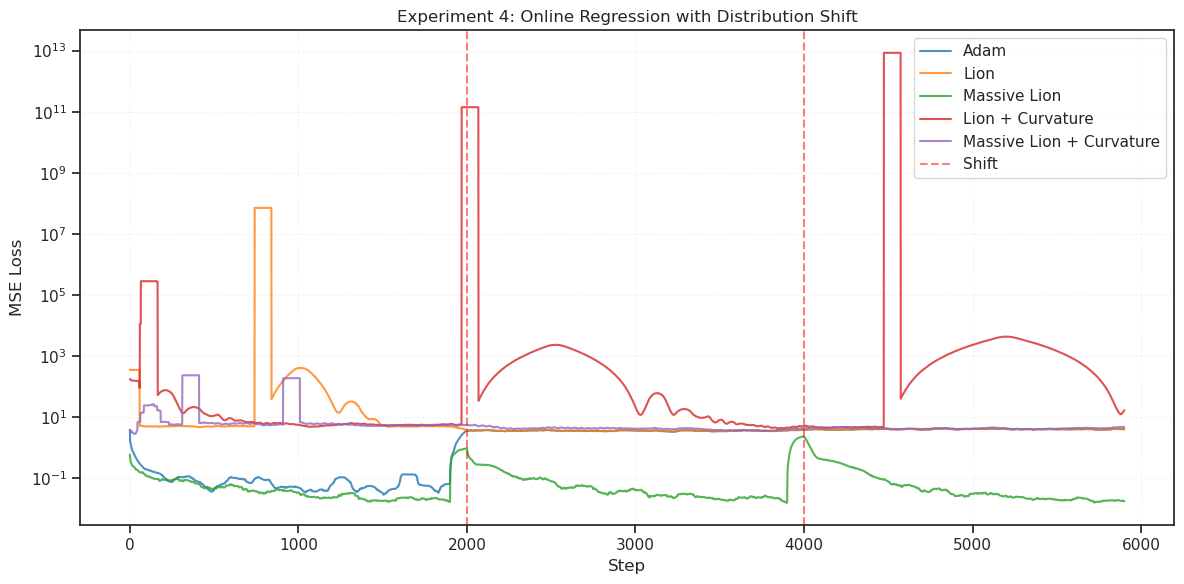

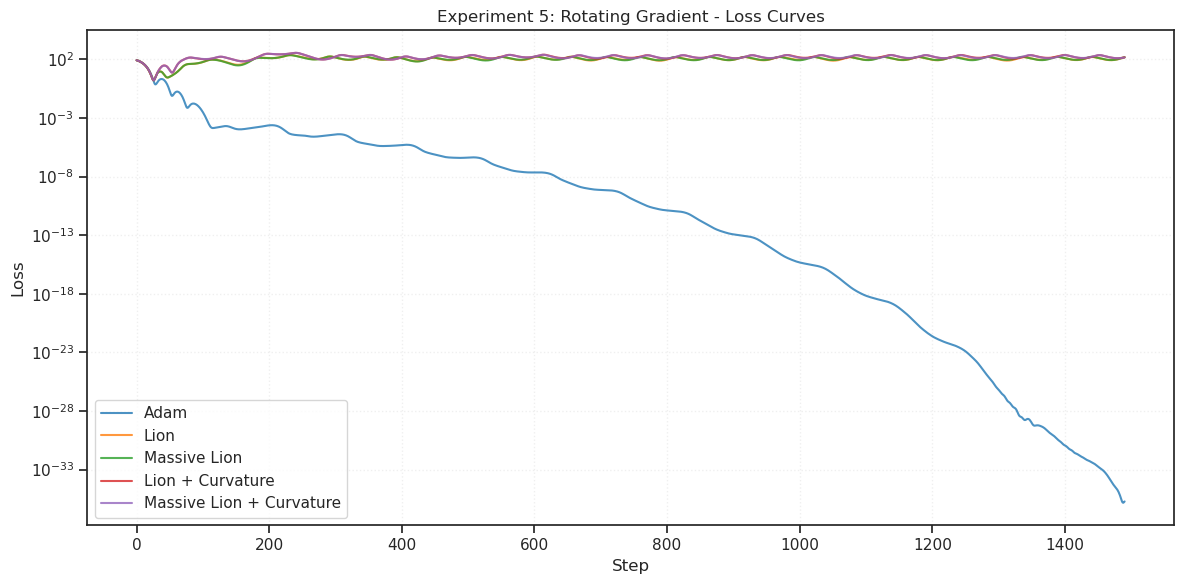

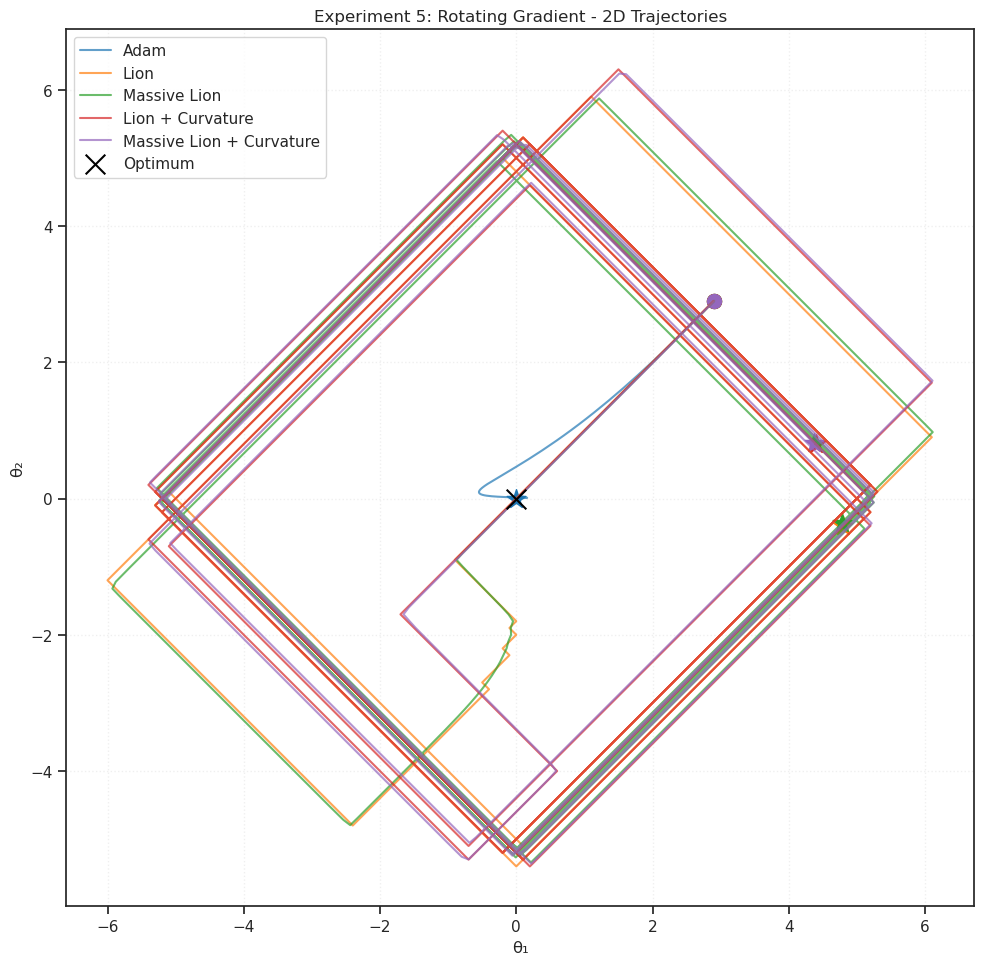

In [4]:
# Compute and print recovery metrics for abrupt shift
if 'shift' in all_results:
    recovery_metrics = compute_recovery_metrics(
        all_results['shift'],
        shift_times=[1000, 2000],
        metric='distances'
    )
    print_recovery_metrics(recovery_metrics)

# Optional: Run curvature ablation
print("\n" + "=" * 70)
print("Running curvature correction ablation...")
print("=" * 70)
ablation_results = run_curvature_ablation()

Recovery Metrics After Distribution Shifts

----------------------------------------------------------------------

Optimizer                      Spike Ratio     Recovery Time   Asymp. Ratio

----------------------------------------------------------------------

Adam                           32.05           6.0             0.20

...

Lion + Curvature               2.97            18.5            1.51

Massive Lion + Curvature       2.70            17.5            1.34

======================================================================

Running curvature correction ablation...

======================================================================

In [2]:
from base.dataset import make_dataset

In [3]:
_, vld, _ = make_dataset('ImageNet32', skip_trn=True)

In [6]:
vld[0].shape, vld[1].shape

(torch.Size([50000, 3, 32, 32]), torch.Size([50000]))

In [9]:
len(torch.unique(vld[1]))

1000

In [4]:
t = 0.1
x = torch.linspace(-4, 4, 1000)
y = torch.sigmoid(x)

y2 = indicator = torch.clamp(0.5 * x + 0.5, min=0.0, max=1.0)

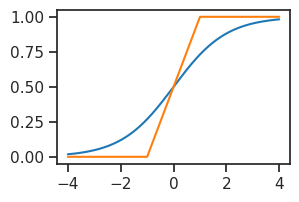

In [5]:
plot(x, y)
plot(x, y2)

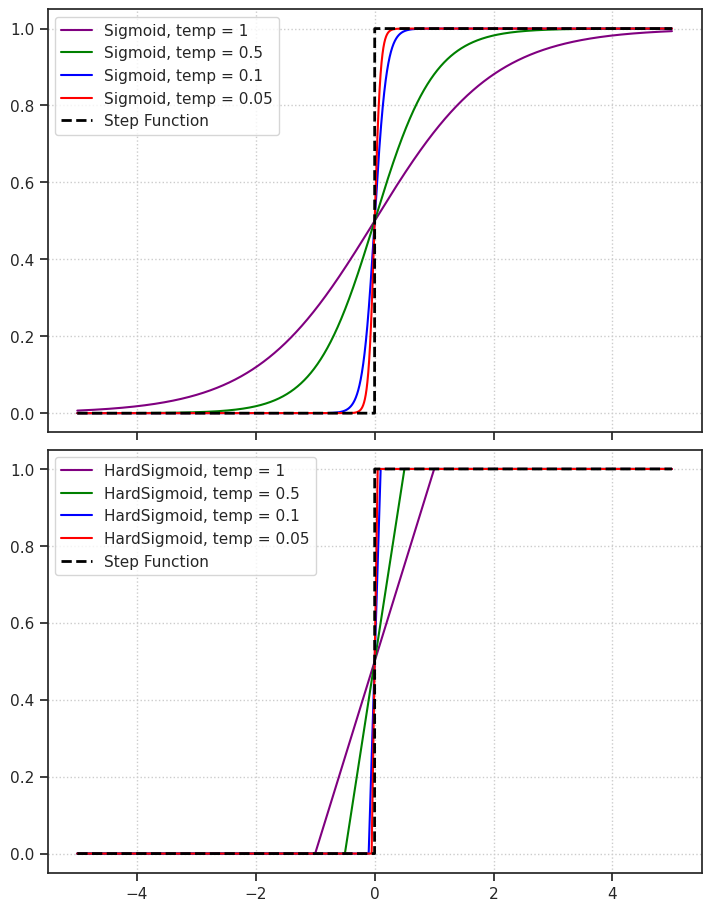

In [27]:
x = torch.linspace(-5, 5, 10000)

fig, axes = create_figure(2, 1, figsize=(7, 9), sharex='all')

temperatures = [1, 0.5, 0.1, 0.05]
colors = ['purple', 'green', 'blue', 'red']
for temp, c in zip(temperatures, colors):
    y = tonp(torch.sigmoid(x / temp))
    axes[0].plot(x, y, label=f'Sigmoid, temp = {temp}', color=c)
    
    y = tonp(torch.clamp(0.5 * x / temp + 0.5, min=0.0, max=1.0))
    axes[1].plot(x, y, label=f'HardSigmoid, temp = {temp}', color=c)

y = tonp(torch.where(x >= 0, 1, 0))
for ax in axes.flat:
    ax.plot(x, y, label='Step Function', color='black', lw=2, ls='--')
    ax.legend()
    ax.grid()
    
plt.show()